# SWOT along-track spectra: Unsmoothed vs. no-aliasing prediction vs. Expert (observed)

This notebook reproduces the comparison at the heart of Du et al. (2026):
whether the red, power-law-like small-scale slopes seen in the SWOT
**Expert** (2-km posting) along-track spectra can be explained purely by
2-D Hamming filtering + subsampling aliasing of the **Unsmoothed**
(250-m posting) field, rather than by ocean dynamics.

Three curves are compared, for a given swath (and optionally cross-track
bin):

1. **Unsmoothed 1-D spectrum** — the observed 250-m posting along-track
   spectrum, `S_1D^250m(kx)`.
2. **No-aliasing prediction** — `S_1D^250m(kx)` passed through the 2-D
   Hamming filter transfer function `|H(kx,ky)|^2` and integrated over
   `ky`, then truncated at the 2-km Nyquist wavenumber (i.e. what the
   Expert-product spectrum *would* look like if subsampling introduced
   no aliasing).
3. **Expert 1-D spectrum (observed)** — the actual observed 2-km posting
   along-track spectrum, computed directly from the Expert granule.

The gap between (2) and (3) is the aliasing signature; the gap between
(1) and (2) is the (already well-understood) noise-floor lowering from
filtering alone.

**Data loading is assumed to already be done** before this notebook's
analysis cells run. You need, before running Section 2:

- Unsmoothed product fields: `ssha_us`, `lat_us`, `lon_us`, `xtrack_us`
  (as returned by e.g. `load_swot_l2()` in `swot_alongtrack_spectra.py`)
- Expert product fields: `ssha_ex`, `lat_ex`, `lon_ex`, `xtrack_ex`
  (as returned by `load_swot_l2_expert()`)

Adjust the variable names in Section 1 if yours differ.

## 0. Imports and module paths

In [1]:
import sys
from pathlib import Path

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cmocean
from scipy import signal

# adjust this if swot_alongtrack_spectra.py / swot_2d_spectra.py live elsewhere
sys.path.insert(0, str(Path.cwd()))

from swot_analysis import (
    compute_pass_spectra,
    split_left_right_swaths,
)
from swot_analysis.swot_2d_spectra import compute_pass_spectra_2d
from swot_analysis import load_swot_l2_expert 
# numpy >= 2.0 renamed trapz -> trapezoid; keep a stable name either way
_trapz = getattr(np, "trapezoid", None) or np.trapz

plt.rcParams["figure.dpi"] = 110

## 1. Inputs

These four blocks are assumed to already exist in the namespace from
your own loading cells (see docstring above). Nothing here re-reads
files — this cell just documents/checks the expected shapes.

In [2]:
# ── Files ──────────────────────────────────────────────────────────────────
DATA_DIR        = '/Volumes/PortableSSD/'
EXPERT_FILE     = 'SWOT_L2_LR_SSH_Expert_0524/SWOT_L2_LR_SSH_Expert_016_074_20240531T192537_20240531T201622_PGD0_01.nc'
UNSMOOTHED_FILE = 'SWOT_L2_LR_SSH_Unsmoothed_016_074_20240531T192538_20240531T201625_PGD0_01.nc'

SSH_VAR = 'ssha_karin_2'
HRET    = False

In [3]:
data_expert = load_swot_l2_expert(DATA_DIR+EXPERT_FILE, ssh_var=SSH_VAR, HRET=HRET)

ds_unsmooth_left = xr.open_dataset(DATA_DIR+UNSMOOTHED_FILE, group='left')
ds_unsmooth_right = xr.open_dataset(DATA_DIR+UNSMOOTHED_FILE, group='right')

ds_unsmooth_left  = ds_unsmooth_left.assign_coords({'num_pixels':ds_unsmooth_left.num_pixels})
ds_unsmooth_right = ds_unsmooth_right.assign_coords({'num_pixels':ds_unsmooth_right.num_pixels+ds_unsmooth_right.num_pixels.values[-1]+1})
ds_unsmooth       = xr.concat([ds_unsmooth_left,ds_unsmooth_right],dim='num_pixels')
ssha = (ds_unsmooth[SSH_VAR] + ds_unsmooth['height_cor_xover'])
for qual_name in (f'{SSH_VAR}_qual', 'ssha_karin_2_qual', 'ssh_karin_2_qual'):
    if qual_name in ds_unsmooth.variables:
        ssha = ssha.where(ds_unsmooth[qual_name] == 0)
        break
for scf in ('ancillary_surface_classification_flag', 'surface_classification_flag'):
    if scf in ds_unsmooth.variables:
        ssha = ssha.where(ds_unsmooth[scf] == 0)
        break
if 'surface_type' in ds_unsmooth.variables:
    ssha = ssha.where(ds_unsmooth['surface_type'] == 0)
    #ssha = np.ma.masked_where(np.abs(ssha)<2,ssha).data
mask = np.where((ssha<2.0)&(ssha>-2.0))
lat = ds_unsmooth['latitude'].values
lon = ds_unsmooth['longitude'].values
xtrack = np.array(ds_unsmooth['cross_track_distance'], dtype='float64')
xtrack = ds_unsmooth['cross_track_distance'].values
ssha = ssha.where(np.abs(ssha)<2.0)

data_unsmoothed = {'ssha': ssha.values, 'latitude': lat,'longitude': lon,'cross_track_distance': xtrack}

/var/folders/fv/pmf052vs1g77j8b23nzvlkmm0000gr/T/ipykernel_19260/1026903993.py:8: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds_unsmooth       = xr.concat([ds_unsmooth_left,ds_unsmooth_right],dim='num_pixels')
/var/folders/fv/pmf052vs1g77j8b23nzvlkmm0000gr/T/ipykernel_19260/1026903993.py:8: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) 

In [4]:
# --- Unsmoothed (250-m posting) product ------------------------------
# ssha_us, lat_us, lon_us : (num_lines, num_pixels)
# xtrack_us               : (num_pixels,) or (num_lines, num_pixels)
ssha_us        = data_unsmoothed['ssha']
lat_us, lon_us = data_unsmoothed['latitude'], data_unsmoothed['longitude']
xtrack_us      = data_unsmoothed['cross_track_distance'] 

# --- Expert (2-km posting) product ------------------------------------
# ssha_ex, lat_ex, lon_ex : (num_lines, num_pixels)
# xtrack_ex               : (num_pixels,) or (num_lines, num_pixels)
ssha_ex        = data_expert['ssha']
lat_ex, lon_ex = data_expert['latitude'], data_expert['longitude']
xtrack_ex      = data_expert['cross_track_distance'] 

for name in ("ssha_us", "lat_us", "lon_us", "xtrack_us",
             "ssha_ex", "lat_ex", "lon_ex", "xtrack_ex"):
    if name not in globals():
        raise NameError(
            f"Expected variable '{name}' not found. Load the Unsmoothed "
            f"and Expert granules before running this notebook (see the "
            f"intro cell for the expected variable names)."
        )

print("Unsmoothed ssha shape:", ssha_us.shape)
print("Expert     ssha shape:", ssha_ex.shape)

Unsmoothed ssha shape: (81927, 480)
Expert     ssha shape: (9866, 69)


## 2. Analysis parameters

`segment_length_km` controls the along-track FFT length / low-`kx`
resolution trade-off for *both* the 1-D and 2-D estimators; keep it
consistent between the two so the comparison is apples-to-apples.
`SWATH` picks which swath ("left" or "right") to analyze; set
`CROSS_TRACK_BIN_KM` to a `(min, max)` tuple of |cross-track distance|
in km to restrict to a cross-track slice (recommended, since SWOT noise
is cross-track inhomogeneous — see Du et al. Section 2b / Fig. 2), or
leave as `None` to use the full swath.

In [26]:
SEGMENT_LENGTH_KM = 50.0     # along-track segment length (km)
OVERLAP = 0.5                # fractional segment overlap
SWATH = "right"              # "left" or "right"
CROSS_TRACK_BIN_KM = None    # e.g. (0.0, 5.0) for a 5-km near-nadir bin, or None for full swath
DETREND = 'constant'

# 2-km posting Nyquist wavenumber (Expert product along-track sampling)
DX_EXPERT_KM = 2.0
K_NY_2KM = 1.0 / (2.0 * DX_EXPERT_KM)   # 0.25 cpkm

# convert SSHA (assumed meters) to cm^2/cpkm units for the plot, to match
# the paper's Fig. 1 convention; set to 1.0 to keep native units instead
SSHA_UNITS_TO_CM = 100.0
PSD_UNIT_SCALE = SSHA_UNITS_TO_CM ** 2

In [27]:
def _restrict_to_cross_track_bin(swath_mask, xtrack, bin_km):
    """AND a swath boolean column-mask with a |cross-track| in [lo, hi] km bin."""
    if bin_km is None:
        return swath_mask
    lo, hi = bin_km
    xt = np.asarray(xtrack, dtype=float)
    if xt.ndim == 2:
        xt = np.nanmedian(xt, axis=0)
    in_bin = (np.abs(xt) >= lo) & (np.abs(xt) < hi)
    return swath_mask & in_bin

## 3. Unsmoothed 1-D along-track spectrum (observed 250-m posting)

Directly from `compute_pass_spectra()`, i.e. the same estimator you
already use for the Zhang & Callies-style plots, run on the Unsmoothed
granule. This is curve (1).

In [28]:
spectra_us_1d = compute_pass_spectra(
    ssha=ssha_us, latitude=lat_us, longitude=lon_us,
    cross_track_distance=xtrack_us,
    segment_length_km=SEGMENT_LENGTH_KM,
    overlap=OVERLAP,
)

left_mask_us, right_mask_us = split_left_right_swaths(xtrack_us)
swath_mask_us = {"left": left_mask_us, "right": right_mask_us}[SWATH]
swath_mask_us = _restrict_to_cross_track_bin(swath_mask_us, xtrack_us, CROSS_TRACK_BIN_KM)

if CROSS_TRACK_BIN_KM is not None:
    from swot_alongtrack_spectra import compute_swath_spectra
    result_us_1d = compute_swath_spectra(
        ssha=ssha_us, latitude=lat_us, longitude=lon_us,
        swath_mask=swath_mask_us, swath_name=SWATH,
        segment_length_km=SEGMENT_LENGTH_KM, overlap=OVERLAP,
        detrend = DETREND
    )
else:
    result_us_1d = spectra_us_1d[SWATH]

kx_us_1d = result_us_1d.wavenumber
psd_us_1d = result_us_1d.mean_psd * PSD_UNIT_SCALE

print(f"Unsmoothed 1-D: {result_us_1d.n_segments_used}/{result_us_1d.n_segments_total} segments used")

Unsmoothed 1-D: 398/809 segments used


## 4. Unsmoothed 2-D spectrum S₀(kx, ky)

Using `compute_pass_spectra_2d()` from `swot_2d_spectra.py`. This keeps
the cross-track wavenumber `ky`, which the 1-D estimator above throws
away, and is the input the filter transfer function needs.

In [29]:
spectra_us_2d = compute_pass_spectra_2d(
    ssha=ssha_us, latitude=lat_us, longitude=lon_us,
    cross_track_distance=xtrack_us,
    segment_length_km=SEGMENT_LENGTH_KM,
    overlap=OVERLAP,detrend = DETREND,
)

if CROSS_TRACK_BIN_KM is not None:
    from swot_2d_spectra import compute_swath_spectra_2d
    result_us_2d = compute_swath_spectra_2d(
        ssha=ssha_us, latitude=lat_us, longitude=lon_us,
        cross_track_distance=xtrack_us,
        swath_mask=swath_mask_us, swath_name=SWATH,
        segment_length_km=SEGMENT_LENGTH_KM, overlap=OVERLAP,detrend = DETREND
    )
else:
    result_us_2d = spectra_us_2d[SWATH]

kx_2d = result_us_2d.wavenumber_x   # cpkm, two-sided (fftshifted)
ky_2d = result_us_2d.wavenumber_y   # cpkm, two-sided (fftshifted)
S0 = result_us_2d.mean_psd_2d       # shape (len(kx_2d), len(ky_2d))

print(f"Unsmoothed 2-D: {result_us_2d.n_segments_used}/{result_us_2d.n_segments_total} segments used")
print("kx_2d range:", kx_2d.min(), kx_2d.max(), " ky_2d range:", ky_2d.min(), ky_2d.max())

Unsmoothed 2-D: 385/809 segments used
kx_2d range: -2.097204218772207 2.077230845260091  ky_2d range: -0.0020002344024690395 0.001983565782448464


## 5. 2-D Hamming-filter transfer function H(kx, ky)

Reproduces the actual 17-point separable Hamming kernel used to
generate the SWOT 2-km posting (Expert) product from the 250-m posting
(Unsmoothed) product, evaluated on the same `(kx, ky)` grid as `S0`
above. The filter operates on the *native Unsmoothed grid spacing*, so
`dx`/`dy` here should be that grid's sample spacing (in km), not the
2-km output spacing.

In [30]:
def hamming_1d_taps(n=17):
    """17-point Hamming kernel, symmetric about 0, unit DC gain."""
    m = np.arange(n) - (n - 1) / 2   # -8 ... 8
    w = 0.54 - 0.46 * np.cos(2 * np.pi * (m + (n - 1) / 2) / (n - 1))
    w = w / w.sum()
    return m, w


def hamming_transfer_1d(k, dx_km, n=17):
    """W(k): 1-D discrete-time Fourier transform of the Hamming kernel,
    evaluated at wavenumber(s) k (cpkm), for a kernel defined on a grid
    with spacing dx_km (km)."""
    m, w = hamming_1d_taps(n)
    k = np.asarray(k, dtype=float)
    # outer sum over taps: shape (..., n) -> sum over last axis
    phase = 2 * np.pi * np.multiply.outer(k, m * dx_km)
    return (w[np.newaxis, :] * np.cos(phase)).sum(axis=-1) if k.ndim else \
           (w * np.cos(phase)).sum()


def hamming_transfer_2d(kx, ky, dx_km, dy_km, n=17):
    """Power transfer function |H(kx,ky)|^2 = W(kx)^2 * W(ky)^2 of the
    separable 2-D Hamming filter, on a meshgrid of kx (along-track) and
    ky (cross-track) wavenumbers."""
    Wx = hamming_transfer_1d(kx, dx_km, n=n)
    Wy = hamming_transfer_1d(ky, dy_km, n=n)
    return np.outer(Wx ** 2, Wy ** 2)


# native Unsmoothed grid spacing, as estimated internally by
# compute_swath_spectra_2d() -- recover it from the kx/ky grids:
dx_native_km = 1.0 / (kx_2d[-1] - kx_2d[-2]) / len(kx_2d) if False else None
# more directly: spacing = 1 / (N * dk), dk = 1/(N*dx) -> dx = 1/(N*dk)
dkx = np.diff(kx_2d).mean()
dky = np.diff(ky_2d).mean()
dx_native_km = 1.0 / (len(kx_2d) * dkx)
dy_native_km = 1.0 / (len(ky_2d) * dky)
print(f"Recovered native grid spacing: dx={dx_native_km:.4f} km, dy={dy_native_km:.4f} km")

H2 = hamming_transfer_2d(kx_2d, ky_2d, dx_native_km, dy_native_km)

# sanity check: half-power point should sit near lambda_c ~ 6.28 km (Chelton 2024)
kx_pos = kx_2d[kx_2d > 0]
Wx_pos = hamming_transfer_1d(kx_pos, dx_native_km) ** 2
k_half = kx_pos[np.argmin(np.abs(Wx_pos - 0.5))]
print(f"Along-track half-power wavenumber: {k_half:.4f} cpkm "
      f"(wavelength {1/k_half:.2f} km; expected ~6.28 km)")

Recovered native grid spacing: dx=0.2384 km, dy=249.9707 km
Along-track half-power wavenumber: 0.1598 cpkm (wavelength 6.26 km; expected ~6.28 km)


## 6. Filtered 2-D spectrum and the no-aliasing 1-D prediction

$$S_{\rm filt}(k_x,k_y) = |H(k_x,k_y)|^2\,S_0(k_x,k_y)$$

$$S_{1D}^{\,2km,\ \rm no\text{-}alias}(k_x) = \int_{-k_{Ny}^{250}}^{k_{Ny}^{250}} S_{\rm filt}(k_x,k_y)\,dk_y,\qquad |k_x|\le k_{Ny}^{2km}$$

In [31]:
S_filt = H2 * S0

# integrate over ky (two-sided, full band) using the trapezoidal rule
S1D_filt_two_sided = _trapz(S_filt, x=ky_2d, axis=1)   # shape (len(kx_2d),)

# also keep the unfiltered along-track integral, as a consistency check
# against the direct 1-D Unsmoothed estimator from Section 3
S1D_us_from2d_two_sided = _trapz(S0, x=ky_2d, axis=1)


def to_one_sided(k, S):
    """Convert a two-sided (fftshifted, kx in [-Nyquist, Nyquist]) 1-D
    spectrum to the one-sided convention (kx in [0, Nyquist], power at
    +/-k folded together) used by scipy.signal.periodogram and hence by
    compute_pass_spectra()."""
    k = np.asarray(k)
    pos = k > 0
    zero = k == 0
    k_os = np.concatenate([k[zero], k[pos]])
    S_os = np.concatenate([S[zero], 2.0 * S[pos]])
    order = np.argsort(k_os)
    return k_os[order], S_os[order]


kx_filt_os, S1D_filt_os = to_one_sided(kx_2d, S1D_filt_two_sided)
kx_us2d_os, S1D_us2d_os = to_one_sided(kx_2d, S1D_us_from2d_two_sided)

# no-aliasing prediction: restrict to the Expert-product Nyquist band
in_2km_band = np.abs(kx_filt_os) <= K_NY_2KM
kx_noalias = kx_filt_os[in_2km_band]
psd_noalias = S1D_filt_os[in_2km_band] * PSD_UNIT_SCALE

print(f"No-aliasing prediction covers kx in [{kx_noalias.min():.4f}, "
      f"{kx_noalias.max():.4f}] cpkm (Expert Nyquist = {K_NY_2KM} cpkm)")

No-aliasing prediction covers kx in [0.0000, 0.2397] cpkm (Expert Nyquist = 0.25 cpkm)


**Consistency check**: `S1D_us2d_os` (the 2-D estimator collapsed to 1-D
by integrating over `ky`) should closely track `psd_us_1d` from Section 3
(the direct 1-D estimator). They use different machinery (2-D Welch +
`ky` integration vs. per-column 1-D Welch averaged over columns), so
exact agreement isn't expected, but the shape and rough amplitude should
match — this is a good sanity check before trusting the filtered
prediction.

In [32]:
# --- 6b. Aliased prediction: fold filtered power across the 2-km Nyquist ---
#
# The no-aliasing prediction above simply truncates S1D_filt_two_sided to
# |kx| <= K_NY_2KM. But the Expert product is generated by *subsampling* the
# Hamming-filtered 250-m field onto the 2-km grid, not by an ideal brick-wall
# low-pass filter -- so power at |kx| > K_NY_2KM doesn't just vanish, it aliases
# back into the observed band at kx (mod 2*K_NY_2KM):
#
#   S_1D^{2km, alias}(kx) = sum_n S_filt_1D(kx + n * 2*K_NY_2KM),  |kx| <= K_NY_2KM
#
# This should track the observed Expert spectrum more closely than the
# no-aliasing prediction if aliasing (rather than ocean dynamics) explains the
# red small-scale tail in the Expert spectra.

fold_period = 2.0 * K_NY_2KM  # cpkm; width of one Nyquist zone for 2-km posting

# two-sided kx axis restricted to the 2-km Nyquist band (mirrors Section 6's
# in_2km_band step, but we fold instead of just truncating)
in_alias_band = np.abs(kx_2d) <= K_NY_2KM
kx_alias_band = kx_2d[in_alias_band]

# how many alias zones does the native (250-m) kx grid span?
n_alias_folds = int(np.ceil(max(-kx_2d.min(), kx_2d.max()) / fold_period)) + 1

S1D_alias_band = np.zeros_like(kx_alias_band)
for n in range(-n_alias_folds, n_alias_folds + 1):
    if n == 0:
        S1D_alias_band += S1D_filt_two_sided[in_alias_band]
    else:
        kx_shifted = kx_alias_band + n * fold_period
        # interpolate the native filtered spectrum onto the shifted wavenumbers;
        # zero contribution once we run off the native grid
        S1D_alias_band += np.interp(
            kx_shifted, kx_2d, S1D_filt_two_sided, left=0.0, right=0.0
        )

kx_alias_os, S1D_alias_os = to_one_sided(kx_alias_band, S1D_alias_band)
kx_alias = kx_alias_os
psd_alias = S1D_alias_os * PSD_UNIT_SCALE

print(f"Aliased prediction covers kx in [{kx_alias.min():.4f}, "
      f"{kx_alias.max():.4f}] cpkm, folding {2*n_alias_folds + 1} Nyquist "
      f"zones (+/-{n_alias_folds} x {fold_period:.4f} cpkm)")

# quick sanity check: aliased power should be >= the no-aliasing prediction
# everywhere (it's the same in-band term plus non-negative folded terms)
frac_extra = np.trapezoid(psd_alias - np.interp(kx_alias, kx_noalias, psd_noalias),
                       x=kx_alias) / np.trapezoid(psd_noalias, x=kx_noalias)
print(f"Aliasing adds ~{100*frac_extra:.1f}% extra power (integrated over kx) "
      f"relative to the no-aliasing prediction")

Aliased prediction covers kx in [0.0000, 0.2397] cpkm, folding 13 Nyquist zones (+/-6 x 0.5000 cpkm)
Aliasing adds ~1.1% extra power (integrated over kx) relative to the no-aliasing prediction


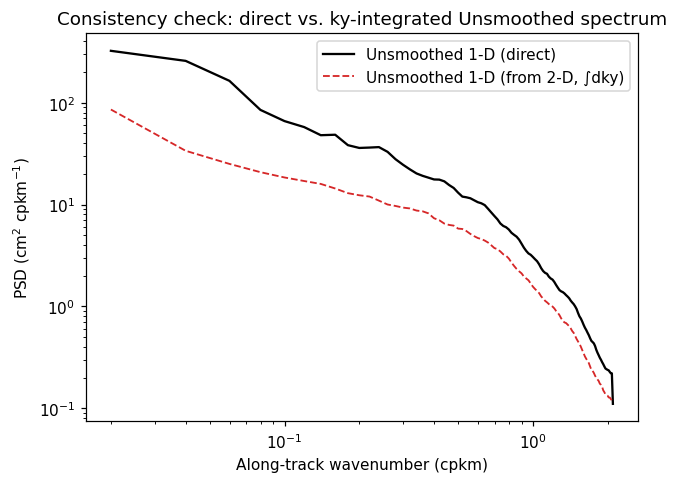

In [33]:
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.loglog(kx_us_1d[kx_us_1d > 0], psd_us_1d[kx_us_1d > 0],
          color="k", lw=1.5, label="Unsmoothed 1-D (direct)")
ax.loglog(kx_us2d_os[kx_us2d_os > 0], S1D_us2d_os[kx_us2d_os > 0] * PSD_UNIT_SCALE,
          color="tab:red", lw=1.2, ls="--", label="Unsmoothed 1-D (from 2-D, ∫dky)")
ax.set_xlabel("Along-track wavenumber (cpkm)")
ax.set_ylabel(f"PSD ({'cm' if SSHA_UNITS_TO_CM != 1 else 'native'}$^2$ cpkm$^{{-1}}$)")
ax.legend()
ax.set_title("Consistency check: direct vs. ky-integrated Unsmoothed spectrum")
fig.tight_layout()

## 7. Expert product 1-D spectrum (observed)

Same `compute_pass_spectra()` estimator, now run on the Expert (2-km
posting) granule. This is curve (3), the actual observed spectrum you
already generate for the Zhang & Callies-style plots.

In [34]:
spectra_ex_1d = compute_pass_spectra(
    ssha=ssha_ex, latitude=lat_ex, longitude=lon_ex,
    cross_track_distance=xtrack_ex,
    segment_length_km=SEGMENT_LENGTH_KM,
    along_track_spacing_km=DX_EXPERT_KM,
    overlap=OVERLAP,detrend = DETREND
)

left_mask_ex, right_mask_ex = split_left_right_swaths(xtrack_ex)
swath_mask_ex = {"left": left_mask_ex, "right": right_mask_ex}[SWATH]
swath_mask_ex = _restrict_to_cross_track_bin(swath_mask_ex, xtrack_ex, CROSS_TRACK_BIN_KM)

if CROSS_TRACK_BIN_KM is not None:
    from swot_alongtrack_spectra import compute_swath_spectra
    result_ex_1d = compute_swath_spectra(
        ssha=ssha_ex, latitude=lat_ex, longitude=lon_ex,
        swath_mask=swath_mask_ex, swath_name=SWATH,
        segment_length_km=SEGMENT_LENGTH_KM,
        along_track_spacing_km=DX_EXPERT_KM, overlap=OVERLAP,detrend = DETREND
    )
else:
    result_ex_1d = spectra_ex_1d[SWATH]

kx_ex_1d = result_ex_1d.wavenumber
psd_ex_1d = result_ex_1d.mean_psd * PSD_UNIT_SCALE

print(f"Expert 1-D: {result_ex_1d.n_segments_used}/{result_ex_1d.n_segments_total} segments used")

Expert 1-D: 417/789 segments used


## 8. Comparison plot

Reproduces the style of Fig. 1 in Du et al. (2026): Unsmoothed spectrum
(dotted), the no-aliasing filtered prediction (dash-dot), and the
observed Expert spectrum (solid). A gap between the dash-dot and solid
lines at small scales is the aliasing signature; a gap between the
dotted and dash-dot lines is the (expected) noise-floor reduction from
filtering alone.

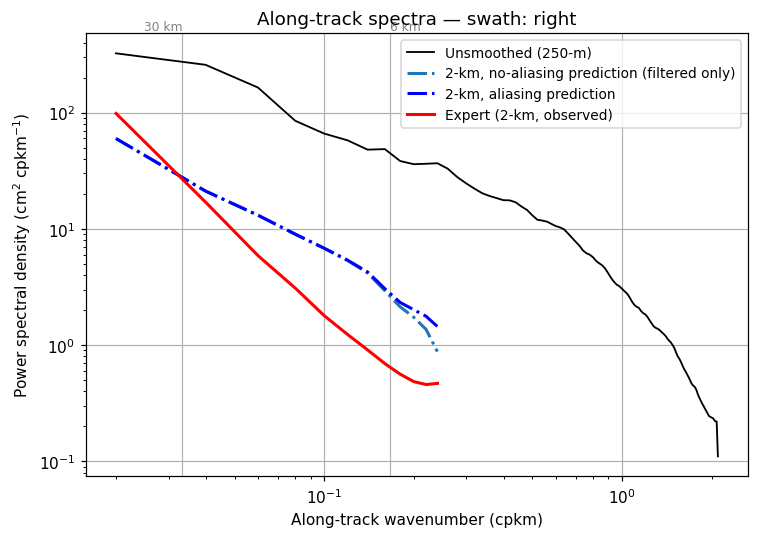

In [40]:
fig, ax = plt.subplots(figsize=(7, 5))

mask_us = kx_us_1d > 0
ax.loglog(kx_us_1d[mask_us], psd_us_1d[mask_us],
          ls="-", color="k", lw=1.2, label="Unsmoothed (250-m)")

ax.loglog(kx_noalias[kx_noalias > 0], psd_noalias[kx_noalias > 0],
          ls="-.", color="tab:blue", lw=2.0,
          label="2-km, no-aliasing prediction (filtered only)")

ax.loglog(kx_alias[kx_alias > 0], psd_alias[kx_alias > 0],
          ls="-.", color="blue", lw=2.0,
          label="2-km, aliasing prediction")

mask_ex = kx_ex_1d > 0
ax.loglog(kx_ex_1d[mask_ex], psd_ex_1d[mask_ex],
          ls="-", color="red", lw=2.0, label="Expert (2-km, observed)")

ax.grid()
ax.axvline(1 / 30.0, color="0.7", lw=0.8, zorder=0)
ax.axvline(1 / 6.0, color="0.7", lw=0.8, zorder=0)
ax.text(1 / 30.0, ax.get_ylim()[1], "30 km", ha="right", va="bottom", fontsize=8, color="0.5")
ax.text(1 / 6.0, ax.get_ylim()[1], "6 km", ha="left", va="bottom", fontsize=8, color="0.5")

ax.set_xlabel("Along-track wavenumber (cpkm)")
ax.set_ylabel(f"Power spectral density ({'cm' if SSHA_UNITS_TO_CM != 1 else 'native'}$^2$ cpkm$^{{-1}}$)")
title_bin = "" if CROSS_TRACK_BIN_KM is None else f", xtrack bin {CROSS_TRACK_BIN_KM} km"
ax.set_title(f"Along-track spectra — swath: {SWATH}{title_bin}")
ax.legend(loc="upper right", fontsize=9)
fig.tight_layout()
#fig.savefig("swot_spectra_comparison.png", dpi=150)

## 9. (Optional) Local spectral slope

Quantifies the visual comparison: local slope $d\log S / d\log k_x$ for
each curve, useful for checking where the no-aliasing prediction and the
observed Expert spectrum agree or diverge in slope, not just amplitude.

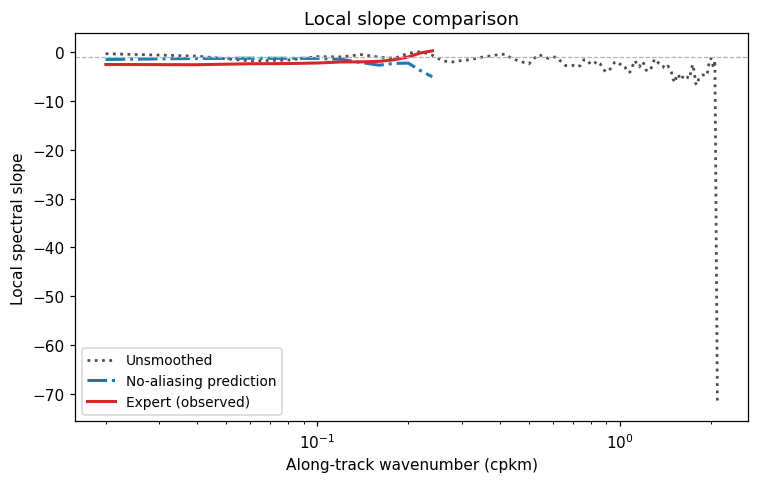

In [36]:
def local_slope(k, S, min_pts=1):
    k = np.asarray(k); S = np.asarray(S)
    logk, logS = np.log10(k), np.log10(S)
    slope = np.gradient(logS, logk)
    return slope


fig, ax = plt.subplots(figsize=(7, 4.5))
ax.semilogx(kx_us_1d[mask_us], local_slope(kx_us_1d[mask_us], psd_us_1d[mask_us]),
            ls=":", color="0.3", lw=1.8, label="Unsmoothed")
ax.semilogx(kx_noalias[kx_noalias > 0],
            local_slope(kx_noalias[kx_noalias > 0], psd_noalias[kx_noalias > 0]),
            ls="-.", color="tab:blue", lw=2.0, label="No-aliasing prediction")
ax.semilogx(kx_ex_1d[mask_ex], local_slope(kx_ex_1d[mask_ex], psd_ex_1d[mask_ex]),
            ls="-", color="tab:red", lw=2.0, label="Expert (observed)")
ax.axhline(-1, color="0.7", lw=0.8, ls="--")
ax.set_xlabel("Along-track wavenumber (cpkm)")
ax.set_ylabel("Local spectral slope")
ax.legend(fontsize=9)
ax.set_title("Local slope comparison")
fig.tight_layout()